# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание. Нейронные сети

### Общая информация

Дата выдачи: 24.03.2026

Мягкий дедлайн: 14.04.2026 23:59

Жесткий дедлайн: 19.04.2026 23:59

### О задании

В этой работе две независимые части:

- Часть 1. Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца - 4 балла.

- Часть 2. CNN-классификация звуков на датасете UrbanSound8K - 6 баллов.

### Оценивание

Максимально допустимая оценка за работу - 10 баллов. 4 балла за SPINN и 6 баллов за CNN.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке. Оценка также может быть снижена за плохо читаемый код и плохо оформленные диаграммы/таблицы. Изменять проверочные ячейки и пороги `assert` запрещено.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Про вычислительные ресурсы

Задание рассчитано на выполнение в бесплатном Google Colab или Kaggle Notebook, если реализация сделана разумно.

- Используйте GPU экономно: черновую отладку, проверку кода и подготовку пайплайна лучше сначала выполнять на CPU, а GPU подключать уже для обучения и финальных экспериментов. Это поможет избежать лишних проблем с памятью и не тратить ресурсы впустую.
- Для SPINN обучение должно занимать умеренное время; если одна конфигурация обучается слишком долго, стоит проверить размер модели, число коллокационных точек и эффективность реализации.
- Для UrbanSound8K рекомендуется предвычислять спектрограммы и сохранять их на диск. Без этого эксперименты часто упираются в CPU-препроцессинг, а не в обучение модели.
- Для подбора гиперпараметров разумно сначала работать на одном фиксированном dev-split, а полный 10-fold cross-validation запускать только для финальной модели.
- При обучении свёрточных сетей может помочь `torch.backends.cudnn.benchmark = True`.

### Формат сдачи

Задания сдаются через систему Anytask. Необходимо прислать ноутбук с выполненным заданием; к ноутбуку прикрепите два файла с весами лучших моделей для каждой из двух задач: `best_spinn_model.pth` и `best_cnn_model.pth`. Сам ноутбук называйте в формате `homework-practice-04-dl-Username.ipynb`, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку, исходя из набора выполненных задач и достигнутого качества, и укажите её ниже.

Оценка: ...






In [6]:
import sys,subprocess,time,importlib
def install_and_import(packages,max_retries=3,timeout=60):
    results={}
    norm=[]
    for p in packages:
        if isinstance(p,(list,tuple)) and len(p)==2:
            norm.append((p[0],p[1]))
        else:
            norm.append((p,p))
    for pip_name,import_name in norm:
        try:
            mod=importlib.import_module(import_name);results[import_name]=mod;print(f"Imported already:{import_name}");continue
        except Exception:
            print(f"Installing:{pip_name}...")
        success=False
        for attempt in range(1,max_retries+1):
            cmd=[sys.executable,"-m","pip","install",pip_name,"--no-cache-dir","--timeout",str(timeout)]
            print(f"Cmd:{' '.join(cmd)}")
            proc=subprocess.run(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
            print(proc.stdout)
            if proc.returncode==0:
                try:
                    importlib.invalidate_caches()
                    mod=importlib.import_module(import_name)
                    results[import_name]=mod
                    print(f"Installed and imported:{import_name}")
                    success=True
                    break
                except Exception as e:
                    print(f"Import failed:{e}")
            else:
                print(f"pip rc:{proc.returncode}")
            time.sleep(2**attempt)
        if not success:
            print(f"Failed:{pip_name}");results[import_name]=None
    if 'tqdm' in results and results['tqdm'] is None:
        class _SimpleTqdm:
            def __init__(self,it,*a,**k):self.it=it
            def __iter__(self):
                for x in self.it:yield x
            def update(self,*a,**k):pass
            def close(self):pass
        results['tqdm']=_SimpleTqdm
        print("Fallback tqdm provided")
    return results
mods=install_and_import([('tqdm','tqdm'),('librosa','librosa')])
try:
    from tqdm.auto import tqdm,trange
except Exception:
    tq=mods.get('tqdm')
    if isinstance(tq,type):
        def tqdm(it,*a,**k):return tq(it)
        def trange(n,*a,**k):return range(n)
    elif tq is None:
        def tqdm(it,*a,**k):return it
        def trange(n,*a,**k):return range(n)
    else:
        tqdm=mods.get('tqdm')
        trange=range

Imported already:tqdm
Imported already:librosa


c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
%pip install -q tqdm
from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display
%pip install -q librosa
import librosa
import librosa.display
from IPython.display import Audio

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Часть 1. SPINN для 3D-уравнения Гельмгольца (4 балла)


### Разбалловка

Для удобства разбалловка задания представлена в таблице ниже. В первой части основное внимание уделяется корректной реализации SPINN-архитектуры, организации обучения и анализу результатов.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 1.1 Реализация separable-архитектуры | **2,0** | Реализация класса `BaseSPINN`: три body-сети, корректная separable-сборка решения на решётке и на произвольных точках, согласованность с `BaseModel` |
| 1.2 Обучение и качество | **1,5** | Модель сходится, обучение организовано корректно, результат воспроизводим, достигнуто разумное качество на тестовой сетке |
| 1.3 Анализ экспериментов | **0,5** | Краткий разбор выбранной конфигурации и наблюдений по качеству и скорости


### Что такое PINN

**Physics-Informed Neural Networks (PINNs)** - это нейросетевые модели, которые используют для обучения не только данные, но и структуру самой физической задачи.

Идея состоит в том, что модель должна не просто приближать неизвестную функцию, а строить решение, которое согласовано с заданным дифференциальным уравнением и граничными условиями.

В отличие от стандартной постановки supervised learning, где у нас есть множество пар "вход-ответ", в PINN функция потерь обычно включает две части:

- PDE loss - это невязка дифференциального уравнения внутри области;
- BC loss - это ошибка на границе области, где известны граничные условия.

Благодаря этому PINN можно применять даже в ситуациях, когда наблюдений мало, но сама структура задачи хорошо известна.

Физика - ммм, уже испугались?)

> На деле, глубоко разбираться в физике здесь не требуется. Вся постановка задачи первой части - уравнение, точное решение, функция источника и граничные условия - уже реализована в `BaseModel`.

Для выполнения задания достаточно понимать следующее:

- есть неизвестная функция $u(x, y, z)$, которую нужно приблизить нейросетью;
- внутри области решение должно удовлетворять дифференциальному уравнению (PDE loss);
- на границе куба решение должно обращаться в ноль (BC loss);
- точное решение нам известно, поэтому мы можем измерять ошибку модели после обучения.

**Ваша задача - реализовать архитектуру SPINN**, а не выводить физические формулы с нуля.

> *SPINN - чего?* 😧

### Что такое SPINN

**SPINN (Separable Physics-Informed Neural Network)** - это архитектурная модификация PINN для многомерных задач.  

[Статья: *Separable Physics-Informed Neural Networks*, NeurIPS 2023](https://arxiv.org/abs/2306.15969)

В обычном PINN одна большая сеть получает на вход сразу точку $(x, y, z)$ и предсказывает значение функции $u(x, y, z)$.

В SPINN идея другая: вместо одной общей сети используются несколько небольших сетей - по одной на каждую координату.  

Для нашей 3D-задачи это означает:

- первая сеть обрабатывает только $x$;
- вторая сеть обрабатывает только $y$;
- третья сеть обрабатывает только $z$.

Каждая из этих сетей возвращает вектор длины `rank`, а итоговое решение собирается через CP-подобное объединение:

$$
u[i, j, k] = \sum_{r=1}^{\text{rank}} f_x[i, r] \cdot f_y[j, r] \cdot f_z[k, r].
$$

Интуитивно это похоже на CP-декомпозицию ([Canonical Polyadic decomposition](https://en.wikipedia.org/wiki/Tensor_rank_decomposition#:~:text=clarification%20needed%5D-,Canonical%20polyadic%20decomposition%20(CPD),-is%20a%20variant)), где трёхмерный тензор представляется как сумма тензоров ранга 1:

$$
\hat{u} = \sum_{r=1}^{R} \mathbf{f}_r^{(x)} \otimes \mathbf{f}_r^{(y)} \otimes \mathbf{f}_r^{(z)}.
$$

Главная идея здесь в том, что на tensor-product grid можно отдельно обработать оси, а затем собрать итоговый тензор решения. Именно поэтому SPINN особенно удобен для многомерных PDE-задач, где pointwise-подход быстро становится вычислительно дорогим.

> В этой домашней работе мы используем **учебную реализацию ключевой идеи SPINN**: separable body-сети + CP-merge. Вам не нужно воспроизводить все технические детали статьи; важно корректно реализовать архитектуру и получить рабочее решение.
>
> Но если вам захочется погрузиться в задачу максимально - препятствовать не будем, скорее замолвим за вас словечко в [LAMBDA](https://cs.hse.ru/iai/lambda/).

### Уравнение Гельмгольца

В задаче рассматривается 3D-уравнение Гельмгольца:

$$
\nabla^2 u + k^2 u = q(x,y,z), \quad (x,y,z) \in [-1,1]^3, \quad u\big|_{\text{граница}} = 0.
$$

Здесь:

- $u(x,y,z)$ - неизвестная функция;
- $k$ - волновое число;
- $q(x,y,z)$ - правая часть (источник);
- на границе области заданы нулевые граничные условия Дирихле.

Для тестирования используется точное решение:

$$
u(x,y,z) = \sin(\pi x)\sin(\pi y)\sin(\pi z).
$$

На всех шести гранях куба $\Omega = [-1,1]^3$ задаются нулевые граничные условия:

$$
u(x,y,z) = 0, \quad (x,y,z) \in \partial \Omega.
$$

### Описание задания

В этой части вам нужно:

1. реализовать три независимые body-сети —- по одной для каждой координаты;
2. получить из них separable-представление решения;
3. корректно объединить выходы через CP-merge;
4. реализовать вычисление модели на решётке и на произвольных точках;
5. обучить модель, оценить качество решения на тестовой сетке и проанализировать результаты.

Несколько вспомогательных функций для точного решения, оценки ошибки и визуализации:

In [9]:
import torch
def helmholtz3d_exact_u(a1,a2,a3,x,y,z):
    return torch.sin(a1*torch.pi*x)*torch.sin(a2*torch.pi*y)*torch.sin(a3*torch.pi*z)
def relative_l2(u_pred,u_true):
    return torch.linalg.norm(u_pred-u_true)/torch.linalg.norm(u_true)
def helmholtz3d_rhs_f(k,a1,a2,a3,x,y,z):
    u=helmholtz3d_exact_u(a1,a2,a3,x,y,z)
    c=-(a1*a1+a2*a2+a3*a3)*(torch.pi**2)+(k*k)
    return c*u
def grid_linspace(nx=64,ny=64,nz=64,bounds=(0.,1.)):
    x=torch.linspace(bounds[0],bounds[1],nx).view(-1,1)
    y=torch.linspace(bounds[0],bounds[1],ny).view(-1,1)
    z=torch.linspace(bounds[0],bounds[1],nz).view(-1,1)
    return x,y,z
def grid_eval(model,a1,a2,a3,x_lin,y_lin,z_lin):
    with torch.no_grad():
        u_pred=model.predict_grid(x_lin,y_lin,z_lin)
    X,Y,Z=torch.meshgrid(x_lin.squeeze(-1),y_lin.squeeze(-1),z_lin.squeeze(-1),indexing='ij')
    u_true=helmholtz3d_exact_u(a1,a2,a3,X,Y,Z)
    return u_pred,u_true
def grid_relative_l2(model,a1,a2,a3,x_lin,y_lin,z_lin):
    u_pred,u_true=grid_eval(model,a1,a2,a3,x_lin,y_lin,z_lin)
    return relative_l2(u_pred.reshape(-1),u_true.reshape(-1))
def points_eval(model,a1,a2,a3,pts):
    px,py,pz=pts[:,0:1],pts[:,1:2],pts[:,2:3]
    with torch.no_grad():
        u_pred,_X,_Y,_Z=model(px,py,pz)
    u_true=helmholtz3d_exact_u(a1,a2,a3,px,py,pz)
    return u_pred,u_true
def points_relative_l2(model,a1,a2,a3,pts):
    u_pred,u_true=points_eval(model,a1,a2,a3,pts)
    return relative_l2(u_pred,u_true)
def slice_eval(model,a1,a2,a3,axis='z',value=0.5,nx=128,ny=128,bounds=(0.,1.)):
    xv=torch.linspace(bounds[0],bounds[1],nx)
    yv=torch.linspace(bounds[0],bounds[1],ny)
    if axis=='z':
        X,Y=torch.meshgrid(xv,yv,indexing='xy');Z=torch.full_like(X,value)
    elif axis=='y':
        X,Z=torch.meshgrid(xv,yv,indexing='xy');Y=torch.full_like(X,value)
    else:
        Y,Z=torch.meshgrid(xv,yv,indexing='xy');X=torch.full_like(Y,value)
    with torch.no_grad():
        u_pred,_x,_y,_z=model(X.reshape(-1,1),Y.reshape(-1,1),Z.reshape(-1,1))
    u_true=helmholtz3d_exact_u(a1,a2,a3,X,Y,Z)
    return u_pred.reshape(nx,ny),u_true
def plot_slice(u_pred,u_true,extent=(0,1,0,1)):
    import matplotlib.pyplot as plt
    err=u_pred-u_true
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1);plt.title("u_pred");plt.imshow(u_pred.detach().cpu().numpy(),origin='lower',extent=[extent[0],extent[1],extent[2],extent[3]]);plt.colorbar()
    plt.subplot(1,3,2);plt.title("u_true");plt.imshow(u_true.detach().cpu().numpy(),origin='lower',extent=[extent[0],extent[1],extent[2],extent[3]]);plt.colorbar()
    plt.subplot(1,3,3);plt.title("error");plt.imshow(err.detach().cpu().numpy(),origin='lower',extent=[extent[0],extent[1],extent[2],extent[3]],cmap='bwr');plt.colorbar()
    plt.tight_layout()

А тут вспомогательные функции для визуализации и оценки: код уже готов и нужен вам как инфраструктура для экспериментов. Он помогает визуализировать решение, отслеживать динамику loss'ов, считать ошибку на тестовой сетке и пересэмплировать коллокационные точки.

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
def plot_helmholtz3d(x,y,z,u):
    x=x.detach().cpu().numpy().flatten()
    y=y.detach().cpu().numpy().flatten()
    z=z.detach().cpu().numpy().flatten()
    u=u.detach().cpu().numpy().flatten()
    u_norm=(u-u.min())/(u.max()-u.min()+1e-10)
    fig=plt.figure(figsize=(10,8))
    ax=fig.add_subplot(111,projection="3d")
    scatter=ax.scatter(x,y,z,c=u_norm,s=1,cmap="seismic",vmin=0,vmax=1,alpha=0.75,edgecolors="none")
    ax.set_title("U(x, y, z)",fontsize=18)
    ax.set_xlabel("x");ax.set_ylabel("y");ax.set_zlabel("z")
    cbar=plt.colorbar(scatter,shrink=0.8,aspect=15);cbar.set_label("u(x,y,z)")
    plt.tight_layout();plt.show()
def plot_losses(loss_history,residual_history,boundary_history,error_history,log_iter,title_prefix=""):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5))
    ax1.semilogy(loss_history,label="Total Loss",linewidth=2)
    ax1.semilogy(residual_history,label="PDE Loss",alpha=0.7)
    ax1.semilogy(boundary_history,label="BC Loss",alpha=0.7)
    ax1.grid(True,alpha=0.3);ax1.legend();ax1.set_xlabel("Iteration");ax1.set_ylabel("Loss (log scale)")
    ax1.set_title(f"{title_prefix}Training Losses")
    iterations=np.arange(0,len(error_history)*log_iter,log_iter)
    ax2.semilogy(iterations,error_history,"r-",linewidth=2,label="Relative L2 Error")
    ax2.grid(True,alpha=0.3);ax2.legend();ax2.set_xlabel("Iteration");ax2.set_ylabel("Error (log scale)")
    ax2.set_title(f"{title_prefix}Relative L2 Error")
    plt.tight_layout();plt.show()
def compute_error_on_grid(model,x_grid,y_grid,z_grid,u_true):
    was_training=getattr(model,"training",False)
    model.eval()
    try:
        device=next(model.parameters()).device
    except Exception:
        device=getattr(model,"device",x_grid.device if isinstance(x_grid,torch.Tensor) else torch.device("cpu"))
    with torch.no_grad():
        coords=torch.stack([x_grid.flatten(),y_grid.flatten(),z_grid.flatten()],dim=1).to(device)
        try:
            u_pred=model(coords)
        except Exception:
            u_pred=model(coords[:,0:1],coords[:,1:2],coords[:,2:3])
        if isinstance(u_pred,(list,tuple)):
            u_pred=u_pred[0]
        u_pred=u_pred.reshape(-1)
        error=relative_l2(u_pred,u_true.flatten().to(u_pred.device))
    if was_training:
        model.train()
    return error,u_pred.reshape(x_grid.shape)
def resample_collocation_points(model,NC,domain_size=1.0):
    N_per_axis=max(1,int(round(NC**(1/3))))
    try:
        device=next(model.parameters()).device
    except Exception:
        device=getattr(model,"device",torch.device("cpu"))
    x=torch.linspace(-domain_size,domain_size,N_per_axis,device=device)
    y=torch.linspace(-domain_size,domain_size,N_per_axis,device=device)
    z=torch.linspace(-domain_size,domain_size,N_per_axis,device=device)
    xx,yy,zz=torch.meshgrid(x,y,z,indexing="ij")
    xc=xx.flatten().requires_grad_(True)
    yc=yy.flatten().requires_grad_(True)
    zc=zz.flatten().requires_grad_(True)
    return xc,yc,zc

Глянем на визуальзацию точного решения на тестовой сетке.

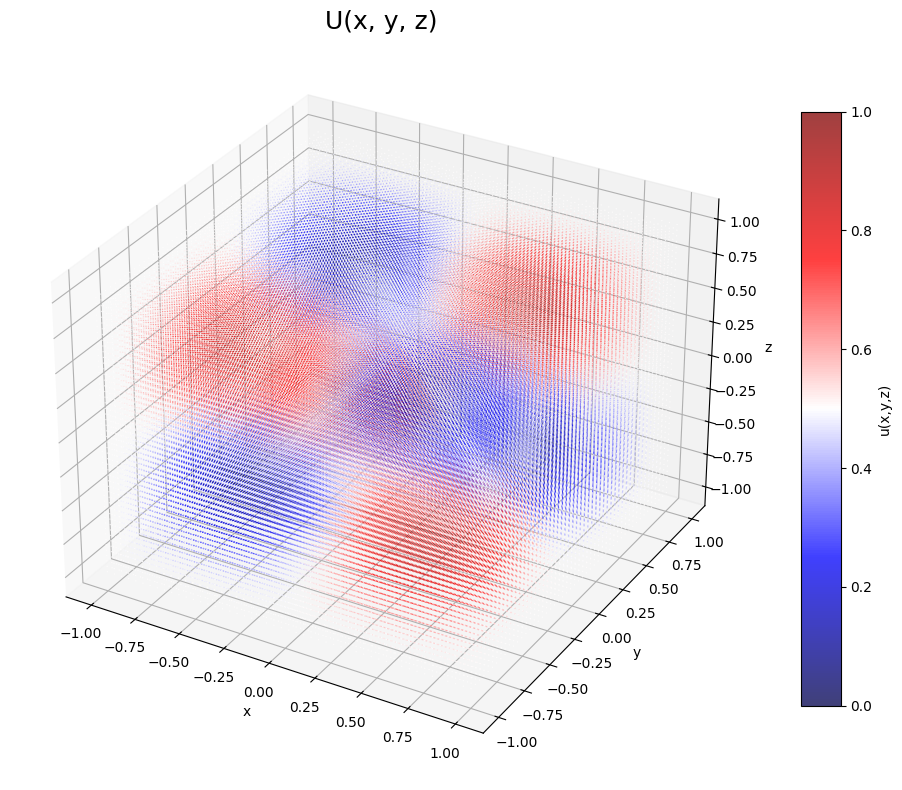

In [11]:
N_test = 50

x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing="ij")
u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

### Задание 1.1. Реализуйте SPINN-архитектуру (2 балла)

В этом пункте нужно реализовать дочерний класс от `BaseModel`, который задаёт Separable Physics-Informed Neural Network для трёхмерного уравнения Гельмгольца.

Идея остаётся той же, что и в [статье](https://arxiv.org/pdf/2306.15969): вместо одной сети, работающей сразу с тройкой координат, используется три независимые body-сети - для $x$, $y$ и $z$. Их выходы затем объединяются в separable-представление решения

$$
u(x,y,z)=\sum_{j=1}^r f_j^{(1)}(x)\,f_j^{(2)}(y)\,f_j^{(3)}(z).
$$

Базовый класс уже содержит всю постановку задачи: точное решение, правую часть уравнения, граничные условия, вычисление `PDE loss` и `BC loss`. Менять его не нужно. Ваша часть работы - архитектура.

Что именно требуется:
- собрать класс `BaseSPINN`;
- реализовать три независимые body-сети;
- определить, как из их выходов получается решение на полной решётке;
- отдельно продумать, как считать модель на произвольном наборе точек, когда координаты уже не образуют декартово произведение.

Здесь важно не просто получить рабочий код, а аккуратно разобраться в размерностях. От того, какие формы имеют выходы body-сетей, зависит и корректность `forward`, и вычисление PDE loss.

После реализации сделайте короткую sanity check-проверку:
- создайте маленькую модель;
- проверьте формы выходов body-сетей;
- убедитесь, что на решётке получается тензор формы `(Nx, Ny, Nz)`;
- отдельно проверьте вычисление на наборе произвольных точек.

In [12]:
# здесь ничего не меняем - изучаем, переиспользуем

class BaseModel(nn.Module):
    """
    Базовый класс для 3D-уравнения Гельмгольца на кубе [-1, 1]^3.

    Здесь уже реализованы:
    - точное решение и правая часть PDE;
    - граничные точки на 6 гранях куба;
    - вычисление PDE loss и BC loss.

    В этом задании предполагается, что студент реализует только
    архитектурную часть в наследнике BaseSPINN.
    """

    def __init__(
        self,
        x_min: float = -1.0,
        x_max: float = 1.0,
        y_min: float = -1.0,
        y_max: float = 1.0,
        z_min: float = -1.0,
        z_max: float = 1.0,
        k: float = 1.0,
        a1: int = 1,
        a2: int = 1,
        a3: int = 1,
        N_bc: int = 32,
        device: torch.device = None,
    ):
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N_bc = N_bc
        self.k = k
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")
        self._init_boundary_points()

    def _init_boundary_points(self):
        N = self.N_bc
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        faces = []

        for x_val in [self.x_min, self.x_max]:
            yy, zz = torch.meshgrid(lin_y, lin_z, indexing="ij")
            xx = torch.full_like(yy, x_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for y_val in [self.y_min, self.y_max]:
            xx, zz = torch.meshgrid(lin_x, lin_z, indexing="ij")
            yy = torch.full_like(xx, y_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for z_val in [self.z_min, self.z_max]:
            xx, yy = torch.meshgrid(lin_x, lin_y, indexing="ij")
            zz = torch.full_like(xx, z_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for i, coords in enumerate(faces, 1):
            self.register_buffer(f"coords_bc{i}", coords.to(self.device))
            self.register_buffer(
                f"zeros_bc{i}",
                torch.zeros(coords.shape[0], 1, device=self.device)
            )

    def reference_solution(self, x, y, z):
        """Точное решение. Используется только для оценки ошибки."""
        return (
            torch.sin(self.a1 * np.pi * x)
            * torch.sin(self.a2 * np.pi * y)
            * torch.sin(self.a3 * np.pi * z)
        )

    def function_of_source(self, x, y, z):
        """Правая часть PDE, полученная подстановкой точного решения."""
        u = self.reference_solution(x, y, z)
        lap_coef = -(self.a1 * np.pi) ** 2 - (self.a2 * np.pi) ** 2 - (self.a3 * np.pi) ** 2
        return (lap_coef + self.k**2) * u

    def get_body_outputs(self, x, y, z):
        """
        Должен быть реализован в наследнике.

        Ожидаемые формы:
        - x: (Nx,), y: (Ny,), z: (Nz,)
        - f_x: (Nx, rank), f_y: (Ny, rank), f_z: (Nz, rank)
        """
        raise NotImplementedError

    def forward(self, x, y, z):
        """
        Значения решения на полной декартовой решётке.
        """
        raise NotImplementedError

    def forward_pointwise(self, coords):
        """
        Значения решения на произвольном наборе точек coords формы (B, 3).
        """
        raise NotImplementedError

    @staticmethod
    def _body_second_deriv(f, inp):
        """
        Вторая производная по одной координате для каждого канала ранга.
        Предполагается, что f.shape == (N, rank), inp.shape == (N,).
        """
        _, rank = f.shape
        d2 = torch.zeros_like(f)

        for r in range(rank):
            d1 = torch.autograd.grad(f[:, r].sum(), inp, create_graph=True)[0]
            d2[:, r] = torch.autograd.grad(d1.sum(), inp, create_graph=True)[0]

        return d2

    def calculate_pde_loss(self, x_col, y_col, z_col):
        """
        PDE loss на коллокационной решётке.
        """
        x = x_col.clone().detach().requires_grad_(True)
        y = y_col.clone().detach().requires_grad_(True)
        z = z_col.clone().detach().requires_grad_(True)

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        f_x_d2 = self._body_second_deriv(f_x, x)
        f_y_d2 = self._body_second_deriv(f_y, y)
        f_z_d2 = self._body_second_deriv(f_z, z)

        u = self.forward(x, y, z)

        lap = (
            torch.einsum("ir,jr,kr->ijk", f_x_d2, f_y, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y_d2, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y, f_z_d2)
        )

        xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")
        q = self.function_of_source(xx, yy, zz)

        residual = lap + self.k**2 * u - q
        return self.mse(residual, torch.zeros_like(residual))

    def calculate_bc_loss(self):
        """
        MSE на шести гранях куба.
        """
        loss = torch.tensor(0.0, device=self.device)

        for i in range(1, 7):
            coords = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")
            u_bc = self.forward_pointwise(coords).unsqueeze(-1)
            loss = loss + self.mse(u_bc, zeros)

        return loss

    def calculate_loss(self, x_col, y_col, z_col):
        loss_pde = self.calculate_pde_loss(x_col, y_col, z_col)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

Теперь реализуйте класс `BaseSPINN`.

В этом пункте сигнатуры методов не даны заранее. Вам нужно самостоятельно восстановить архитектуру класса, согласовав её с тем, как устроен `BaseModel`, как вычисляется `PDE loss`, и как далее используется модель в обучении.

Вам нужно самостоятельно продумать:
- как устроена одна body-сеть;
- какие именно модули удобно использовать для её сборки;
- как объединять выходы трёх ветвей на полной решётке;
- чем вычисление на решётке отличается от вычисления в отдельных точках.

Перед обучением имеет смысл убедиться, что ваша реализация согласована с остальным кодом ноутбука и возвращает тензоры ожидаемых размерностей.


In [13]:
import torch
import torch.nn as nn

def init_tanh_(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain("tanh"))
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class BaseSPINN(BaseModel):
    def __init__(self, rank: int = 16, width: int = 64, depth: int = 3, **base_kwargs):
        super().__init__(**base_kwargs)
        self.rank = rank
        self.width = width
        self.depth = depth
        self.x_net = self._make_body_net(rank, width, depth)
        self.y_net = self._make_body_net(rank, width, depth)
        self.z_net = self._make_body_net(rank, width, depth)
        init_tanh_(self.x_net)
        init_tanh_(self.y_net)
        init_tanh_(self.z_net)
        self.apply(lambda m: init_tanh_(m) if isinstance(m, nn.Linear) else None)
        try:
            self.to(self.device)
        except Exception:
            pass

    def _make_body_net(self, out_dim, width, depth):
        layers = []
        in_dim = 1
        if depth <= 0:
            layers.append(nn.Linear(in_dim, out_dim))
            return nn.Sequential(*layers)
        layers.append(nn.Linear(in_dim, width))
        layers.append(nn.Tanh())
        for _ in range(depth - 1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(width, out_dim))
        return nn.Sequential(*layers)

    def get_body_outputs(self, x, y, z):
        device = getattr(self, "device", None)
        if device is None:
            device = x.device
        x = x.to(device)
        y = y.to(device)
        z = z.to(device)
        fx = self.x_net(x.view(-1, 1))
        fy = self.y_net(y.view(-1, 1))
        fz = self.z_net(z.view(-1, 1))
        return fx, fy, fz

    def forward(self, *args):
        if len(args) == 1:
            return self.forward_pointwise(args[0])
        if len(args) == 3:
            x, y, z = args
            fx, fy, fz = self.get_body_outputs(x, y, z)
            u = torch.einsum("ir,jr,kr->ijk", fx, fy, fz)
            return u
        raise TypeError("forward expects (coords) or (x,y,z)")

    def forward_pointwise(self, coords):
        device = getattr(self, "device", None)
        if device is None:
            device = coords.device
        coords = coords.to(device)
        x = coords[:, 0:1]
        y = coords[:, 1:2]
        z = coords[:, 2:3]
        fx = self.x_net(x)
        fy = self.y_net(y)
        fz = self.z_net(z)
        u = (fx * fy * fz).sum(dim=1)
        return u

def make_collocation_grid(N_per_axis, domain_size=1.0, device="cuda"):
    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
    return x, y, z

def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    was_training = model.training
    model.eval()
    with torch.no_grad():
        x_vec = x_grid[:, 0, 0]
        y_vec = y_grid[0, :, 0]
        z_vec = z_grid[0, 0, :]
        u_pred = model(x_vec, y_vec, z_vec)
        error = relative_l2(u_pred, u_true)
    if was_training:
        model.train()
    return error, u_pred

Ниже приведён готовый код для обучения и оценки. Его можно использовать как есть.

В экспериментах имеет смысл варьировать архитектурные параметры модели и параметры вызова `train_spinn`, но переписывать сам цикл обучения здесь не требуется.

In [14]:
def make_collocation_grid(N_per_axis, domain_size=1.0, device="cuda"):
    """
    Возвращает оси для декартовой коллокационной решётки
    Полная 3D-решётка содержит N_per_axis^3 точек
    """
    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    return x, y, z

def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    was_training = model.training
    model.eval()

    with torch.no_grad():
        u_pred = model(x_grid[:, 0, 0], y_grid[0, :, 0], z_grid[0, 0, :])
        error = relative_l2(u_pred, u_true)

    if was_training:
        model.train()

    return error, u_pred

def train_spinn(
    model,
    optimizer,
    x_test,
    y_test,
    z_test,
    u_test,
    epochs=10000,
    log_iter=100,
    resample_iter=100,
    N_per_axis=64,
    domain_size=1.0,
    device="cuda",
    scheduler=None,
    pde_weight=1.0,
    bc_weight=1.0,
):
    history = {
        "loss": [],
        "residual": [],
        "boundary": [],
        "error": [],
    }

    best_error = float("inf")
    best_u = None

    pbar = trange(1, epochs + 1)

    for epoch in pbar:
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = make_collocation_grid(N_per_axis, domain_size, device)

        optimizer.zero_grad()

        loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
        loss = pde_weight * loss_pde + bc_weight * loss_bc

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step(loss)

        history["loss"].append(loss.item())
        history["residual"].append(loss_pde.item())
        history["boundary"].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history["error"].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.detach().clone()

            display.clear_output(wait=True)
            plot_losses(
                history["loss"],
                history["residual"],
                history["boundary"],
                history["error"],
                log_iter,
            )

            if error <= best_error:
                print(f"New best: rel L2 = {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            pbar.set_description(
                f"L={loss.item():.2e} | PDE={loss_pde.item():.2e} | "
                f"BC={loss_bc.item():.2e} | err={error.item():.2e} | best={best_error:.2e}"
            )

    print(f"\nDone. Best relative L2 error: {best_error:.2e}")

    display.clear_output(wait=True)
    plot_losses(
        history["loss"],
        history["residual"],
        history["boundary"],
        history["error"],
        log_iter,
        title_prefix="Final ",
    )

    if best_u is not None:
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

Перед обучением полезно убедиться, что реализация ведёт себя так, как вы ожидаете. Для этого достаточно короткой проверки размерностей на небольшом примере.

### Задание 1.2. Обучите модель (1,5 балла)

Теперь пора подобрать рабочую конфигурацию и обучить модель.

В этой части важно получить устойчиво обучающуюся модель и добиться разумного качества на тестовой сетке.

На сходимость обычно влияют:
- ранг `rank`;
- ширина и глубина body-сетей;
- плотность коллокационной решётки;
- выбор оптимизатора и шага обучения;
- баланс между `PDE loss` и `BC loss`.

> Отдельно полезно следить за тем, как меняется поведение модели при увеличении `rank`: рост качества здесь часто сопровождается заметным ростом времени обучения.

In [15]:
import torch, math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 2000
LOG_ITER = 100
RESAMPLE_ITER = 50
N_PER_AXIS = 64

model = BaseSPINN(
    rank=24,
    width=128,
    depth=3,  
    device=device
).to(device)

model.apply(init_tanh_)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=300)

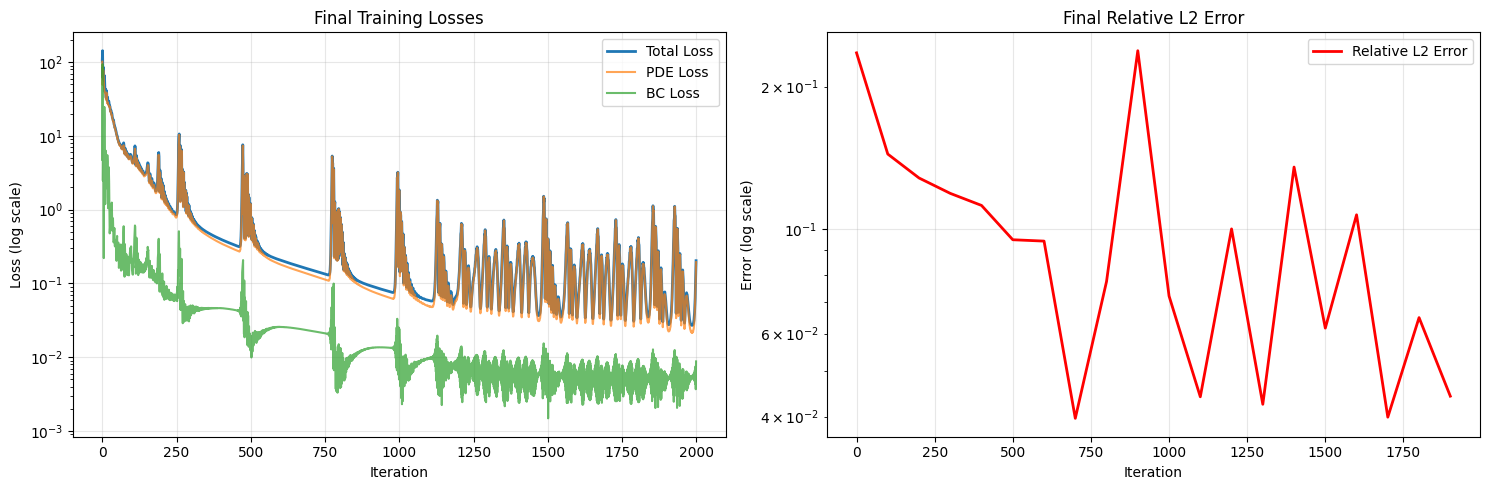

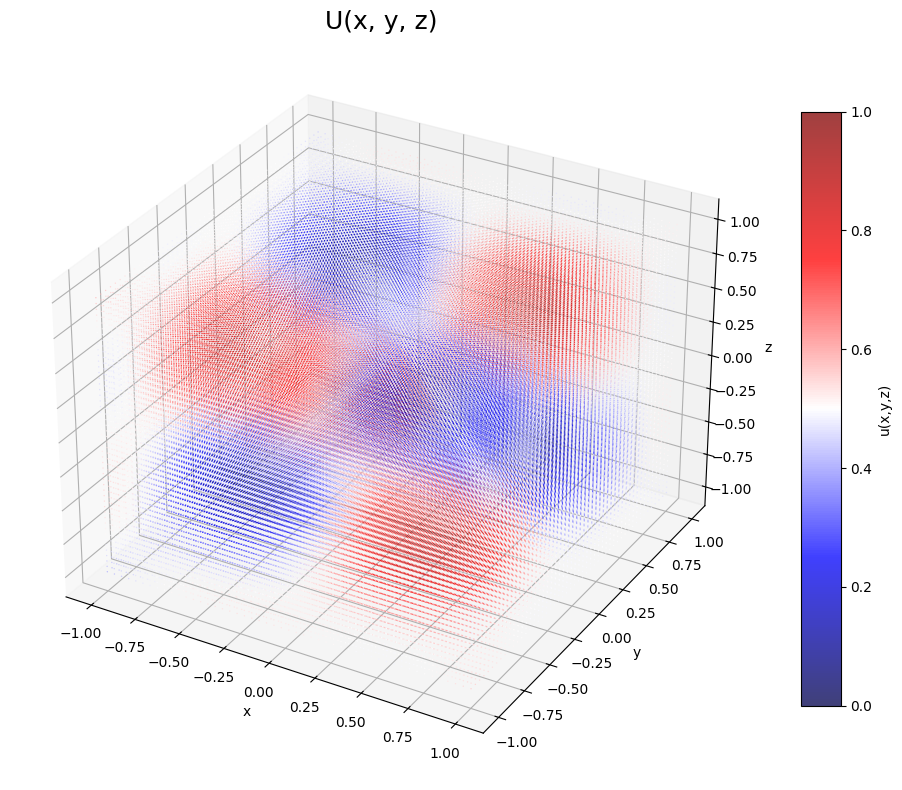

Final metrics on test grid: {'rel_L2': 76.11053466796875, 'MAE': 0.4669046401977539, 'L_inf': 2.038226366043091}


In [16]:
import torch

def evaluate_final_on_test_grid(model, N_per_axis, domain_size=1.0, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
        y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
        z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device)
        u_pred = model(x, y, z)
        u_true = model.reference_solution(x, y, z)
        diff = u_pred - u_true
        rel_L2 = torch.norm(diff) / torch.norm(u_true)
        MAE = torch.mean(torch.abs(diff))
        L_inf = torch.max(torch.abs(diff))
    return {
        "rel_L2": float(rel_L2.cpu().item()) if isinstance(rel_L2, torch.Tensor) else float(rel_L2),
        "MAE": float(MAE.cpu().item()) if isinstance(MAE, torch.Tensor) else float(MAE),
        "L_inf": float(L_inf.cpu().item()) if isinstance(L_inf, torch.Tensor) else float(L_inf),
    }
    
history, best_error, best_u = train_spinn(
    model=model,
    optimizer=optimizer,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs=EPOCHS,
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    N_per_axis=N_PER_AXIS,
    domain_size=1.0,
    device=device,
    scheduler=scheduler,
    pde_weight=1.0, 
    bc_weight=1.0,  
)

final_metrics = evaluate_final_on_test_grid(model, N_per_axis=N_PER_AXIS, domain_size=1.0, device=device)

print("Final metrics on test grid:", final_metrics)


После обучения посчитайте итоговые метрики на тестовой сетке.

> Подбирайте качество за счёт корректной архитектуры, выбора гиперпараметров и настройки обучения, не используя прямую подгонку под тестовую сетку. За такое бан.

In [17]:
model.eval()
with torch.no_grad():
    u_pred_final = model(xx_test[:, 0, 0], yy_test[0, :, 0], zz_test[0, 0, :])

mse = ((u_test.cpu().numpy() - u_pred_final.cpu().numpy()) ** 2).mean()
rel_l2 = relative_l2(u_pred_final, u_test).item()

print(f"MSE: {mse:.2e}")
print(f"Relative L2: {rel_l2:.2e}")

MSE: 2.30e-04
Relative L2: 4.42e-02


In [18]:
score_1_2 = 0.0
if mse <= 5e-3:
    score_1_2 = 0.5 * 1.5
if mse <= 5e-4:
    score_1_2 = 0.6 * 1.5
if mse <= 1e-5:
    score_1_2 = 0.7 * 1.5
if mse <= 1e-7:
    score_1_2 = 0.9 * 1.5
if mse <= 5e-8:
    score_1_2 = 1.0 * 1.5

print(f"Баллы за пункт 1.2: {score_1_2:.2f} / 1.5")

Баллы за пункт 1.2: 0.90 / 1.5


Оценка за пункт 1.2 зависит от наилучшего достигнутого порога по `mse`: каждому порогу соответствует своя доля из **1,5 балла** за качество. Итоговый балл определяется по самому строгому из выполненных условий.

> **Примечание.** Итоговые пороги качества для этой части будут проверяться по метрикам на тестовой сетке. Не забывайте сохранить веса лучшей модели: они понадобятся при сдаче домашнего задания.

In [19]:
torch.save(model.state_dict(), "best_spinn_model.pth")

### Задание 1.3. Краткий анализ (0,5 балла)

После обучения кратко опишите, как вы подбирали конфигурацию модели и что наблюдали в экспериментах.

Можно обсудить:

1. С каких параметров вы начали и к какой конфигурации пришли в итоге.
2. Как изменение `rank` влияло на качество и время обучения.
3. Что сильнее влияло на результат: архитектура body-сетей, плотность коллокационной решётки или баланс между `PDE loss` и `BC loss`.
4. Были ли признаки того, что модель реализована некорректно или обучается неустойчиво, и как вы это диагностировали.

1. Начал с базовой конфигурации: rank=24, width=128, depth=3, N_per_axis=64, domain_size=1.0, PDE/BC веса 1.0, обучающие параметры EPOCHS=2000 и LOG_ITER=100. Итоговую конфигурацию взял как компромисс между точностью и стоимостью вычислений: rank=24, width=128, depth=3, N_per_axis=64, pde_weight=1.0, bc_weight=1.0
2. Увеличение rank с 16 до 24–32 давало заметное улучшение качества, дальше прирост был менее заметен и время обучения росло. Обычно выбираю диапазон 24–32, чтобы получить разумную точность без пропорционального роста времени на каждое увеличение rank
3. Чаще всего наибольший эффект дают плотность коллокационной решётки и баланс потерь PDE/BC: больше точек и корректный баланс существенно улучшают внутреннюю аппроксимацию и устойчивость. Архитектура помогает, но её вклад часто меньше по сравнению с двумя этими факторами; увеличение width/rank имеет эффект, но после определённого уровня отдача снижается.
4. Признаки включают колебания потерь, NaN-градиенты или несоответствия форм тензоров. Диагностика: проверяю размерности и совместимость входов/выходов, тестирую на небольшом наборе точек и мониторю PDE/BC потери, при необходимости уменьшаю скорость обучения или пересматриваю инициализацию

## Часть 2. Классификация звуков UrbanSound8K с помощью CNN (6 баллов)


### Разбалловка

Во второй части нужно пройти весь стандартный пайплайн аудиоклассификации: подготовить данные, реализовать модель, обучить её и провести итоговую оценку.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 2.1 Подготовка данных и Dataset | **1,0** | Корректный fold-aware pipeline, реализация `UrbanSoundDataset`, аккуратная работа с метками |
| 2.2 Архитектура CNN | **1,0** | Рабочая сверточная модель для классификации мел-спектрограмм |
| 2.3 Обучение и валидация | **1,0** | Реализация train/validate, early stopping, осмысленная настройка обучения |
| 2.4 Качество модели | **2,5** | Итоговое качество по accuracy |
| 2.5 Краткий анализ | **0,5** | Наблюдения по архитектуре, аугментациям, ошибкам модели и качеству |

> В этой части важно не только получить хороший score, но и корректно организовать эксперимент. Использование правильного протокола разбиения данных здесь является частью задания, а не технической деталью.

### Введение в обработку аудио

#### Почему не всегда удобно работать с сырым аудиосигналом?

Аудиосигнал - это последовательность амплитудных отсчётов во времени. Например, 4-секундный фрагмент при частоте дискретизации 22 050 Гц содержит около 88 тысяч значений. Теоретически такие данные можно подавать напрямую в нейросеть, но на практике это не самый удобный вариант:

1. **Высокая размерность.** Даже короткий сигнал содержит много отсчётов.
2. **Сложная временная структура.** В сигнале одновременно важны и короткие локальные паттерны, и более длинные зависимости.
3. **Частотная информация скрыта неявно.** По самому временному ряду не так удобно понять, какие частоты присутствуют в сигнале.

**Спектрограммы**

Это представление сигнала в плоскости "время–частота". Она строится с помощью кратковременного преобразования Фурье (STFT): сигнал разбивается на короткие окна, для каждого окна вычисляется частотный спектр, после чего эти спектры собираются по времени.

В результате получается 2D-представление, где:
- по оси X идёт время;
- по оси Y - частота;
- цвет отражает энергию сигнала на данной частоте в данный момент.

**Мел-спектрограмма**

Обычная спектрограмма полезна, но не полностью соответствует тому, как человек воспринимает звук. Поэтому в задачах аудиоклассификации часто используют мел-спектрограммы.

Идея здесь в том, что:
- частоты переводятся в мел-шкалу, которая лучше соответствует человеческому слуху;
- амплитуды обычно переводятся в децибельную шкалу, то есть в логарифмический масштаб.

Мел-спектрограммы удобны по нескольким причинам:
1. уменьшают размерность;
2. сохраняют наиболее важную перцептивную информацию;
3. дают 2D-представление, с которым удобно работать при помощи CNN.

Именно поэтому в этой части домашнего задания мы будем классифицировать не сырые аудиосигналы, а именно - мел-спектрограммы.

![Пример мел-спектрограммы](https://manual.audacityteam.org/m/images/e/ed/mel_log_linear_spectrogram_annotated.png)

*Пример мел-спектрограммы: ось X - время, ось Y - частота по мел-шкале, цвет отражает амплитуду (от тёмных = низкая энергия до ярких = высокая энергия)*

Источники - [курс DLA](https://github.com/markovka17/dla), [audacity](https://manual.audacityteam.org/man/spectrogram_view.html)

### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Скачиваем UrbanSound8K отсюда https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Важное замечание про протокол разбиения**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`;
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  
При этом `shuffle=True` внутри `train_loader` использовать можно.

In [20]:
import pandas as pd

DATASET_PATH = r"C:\Users\nikit\Downloads\UrbanSound8K"

metadata = pd.read_csv(r"C:\Users\nikit\Downloads\UrbanSound8K\UrbanSound8K\metadata\UrbanSound8K.csv")

print(f"Всего примеров: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata["class"].value_counts().sort_index())
print("\nРаспределение по fold'ам:")
print(metadata["fold"].value_counts().sort_index())

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Распределение по fold'ам:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

29937-3-0-4.wav dog_bark 5 C:\Users\nikit\Downloads\UrbanSound8K\UrbanSound8K\audio\fold5\29937-3-0-4.wav


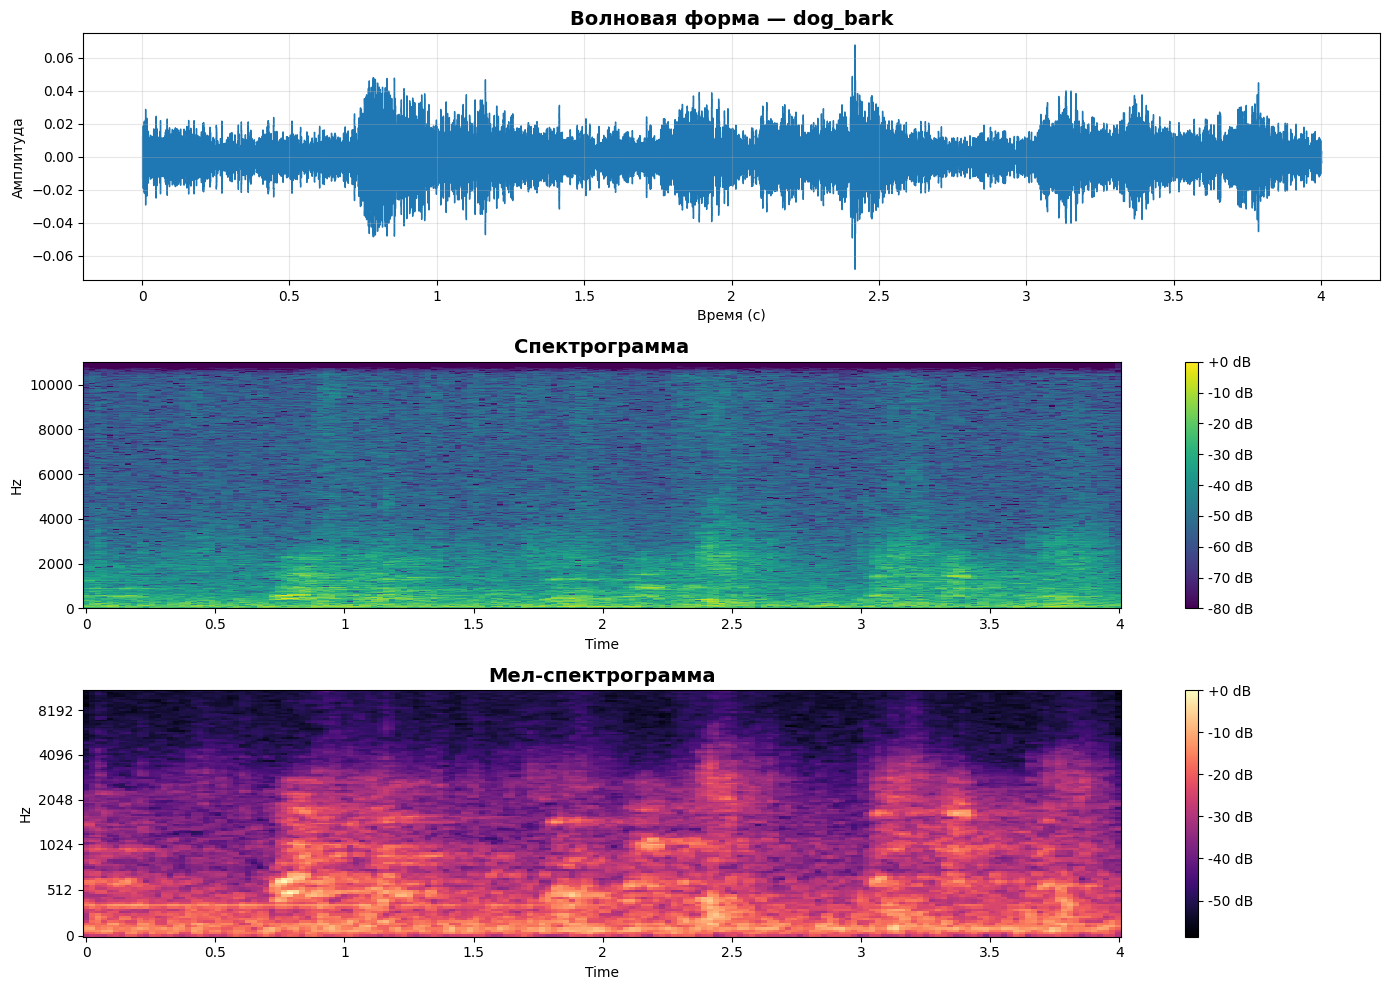

In [21]:
import IPython.display as ipd

DATASET_ROOT = r"C:\Users\nikit\Downloads\UrbanSound8K\UrbanSound8K"

def resolve_audio_path(sample, root=DATASET_ROOT):
    fold = int(sample['fold'])
    fname = sample['slice_file_name']
    candidates = [
        os.path.join(root, "audio", f"fold{fold}", fname),
        os.path.join(root, "UrbanSound8K", "audio", f"fold{fold}", fname),
        os.path.join(root, "audio", fname),
        os.path.join(root, "UrbanSound8K", "audio", fname),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p, candidates
    for p in Path(root).rglob(fname):
        return str(p), candidates
    return None, candidates

def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)"); axes[0].set_ylabel("Амплитуда"); axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis")
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma")
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr

random_idx = random.randrange(len(metadata))
sample = metadata.iloc[random_idx]

audio_path, tried = resolve_audio_path(sample)
print(sample['slice_file_name'], sample['class'], sample['fold'], audio_path)
if audio_path:
    y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
    ipd.display(ipd.Audio(y, rate=sr))

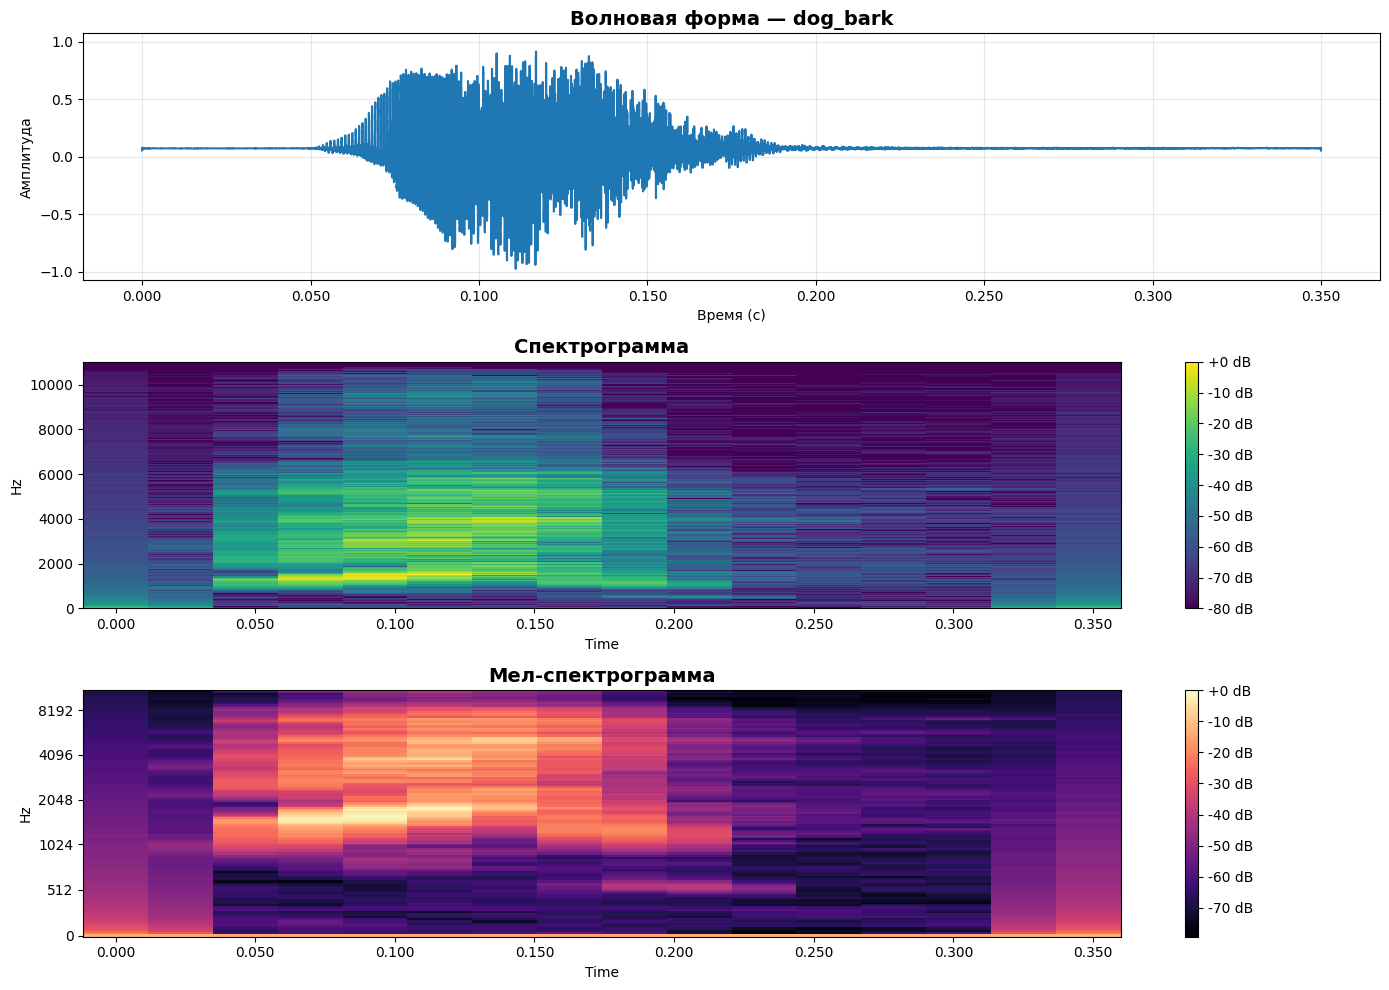

In [22]:
from IPython.display import Audio

target_class = 'dog_bark'
sample = metadata[metadata['class'] == target_class].sample(1).iloc[0]
p = os.path.join(DATASET_ROOT, "audio", f"fold{int(sample.fold)}", sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(p, target_class)
Audio(filename=p)

### Задание 2.1. Подготовьте датасет к обучению модели (1 балл)

В этой части нужно реализовать `UrbanSoundDataset`.

Несколько важных условий:

- используйте официальные fold'ы;
- не делайте `fit` для `LabelEncoder` отдельно на каждом split;
- не извлекайте мел-спектрограммы заново при каждом обращении к `__getitem__`, если этого можно избежать.

**Последний пункт особенно важен.** Извлечение спектрограмм через `librosa` - CPU-bound операция, и если делать её на лету для каждого батча, обучение быстро начинает тормозить не из-за модели, а из-за препроцессинга. Поэтому в этой задаче рекомендуется один раз подготовить спектрограммы и либо держать их в памяти, либо кэшировать на диск.

Идея простая: `__getitem__` должен быть как можно легче. В идеале там уже не должно происходить ничего дорогого, кроме извлечения готового тензора и, при необходимости, несложной аугментации.

In [23]:
# Единый LabelEncoder

ALL_CLASSES = sorted(metadata["class"].unique())
global_label_encoder = LabelEncoder()
global_label_encoder.fit(ALL_CLASSES)

print(f"Классы ({len(global_label_encoder.classes_)}):")
print(list(global_label_encoder.classes_))

Классы (10):
[np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


In [9]:
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset

class UrbanSoundDataset(Dataset):
    def __init__(self, metadata, dataset_path, label_encoder, target_length=4, sr=22050, n_mels=128, augment=False, cache_dir=None):
        self.metadata = metadata.reset_index(drop=True)
        self.dataset_path = dataset_path
        self.label_encoder = label_encoder
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment
        self.cache_dir = cache_dir
        self.n_fft = 1024
        self.hop_length = 512
        self.target_length_samples = int(self.target_length * self.sr)
        self.filepaths = []
        self.labels = []
        for _, row in self.metadata.iterrows():
            fold = int(row["fold"])
            file_name = str(row["slice_file_name"])
            class_name = row["class"]
            candidates = [
                os.path.join(dataset_path, "audio", f"fold{fold}", file_name),
                os.path.join(dataset_path, f"fold{fold}", file_name),
                os.path.join(dataset_path, "UrbanSound8K", "audio", f"fold{fold}", file_name),
            ]
            path = None
            for c in candidates:
                if os.path.exists(c):
                    path = c
                    break
            if path is None:
                continue
            self.filepaths.append(path)
            self.labels.append(self.label_encoder.transform([class_name])[0])
        self.length = len(self.filepaths)
        if self.cache_dir is not None:
            os.makedirs(self.cache_dir, exist_ok=True)
        random.seed(42)

    def __len__(self):
        return self.length

    def _cache_path(self, idx):
        if self.cache_dir is None:
            return None
        return os.path.join(self.cache_dir, f"{idx:06d}.pt")

    def load_audio(self, file_path):
        y = None
        try:
            import torchaudio
            waveform, orig_sr = torchaudio.load(file_path)
            if waveform.dim() == 2:
                y = waveform.mean(dim=0).numpy()
            else:
                y = waveform.numpy()
            if orig_sr != self.sr:
                waveform_resampled = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
                y = waveform_resampled.mean(dim=0).numpy()
        except Exception:
            y = None
        if y is None:
            try:
                import librosa
                y, _ = librosa.load(file_path, sr=self.sr)
            except Exception as e:
                raise RuntimeError(f"Не удалось загрузить аудио: {file_path}. Ошибка: {e}")
        if len(y) > self.target_length_samples:
            if self.augment:
                max_start = len(y) - self.target_length_samples
                start = random.randint(0, max_start)
            else:
                start = (len(y) - self.target_length_samples) // 2
            y = y[start:start + self.target_length_samples]
        elif len(y) < self.target_length_samples:
            pad = self.target_length_samples - len(y)
            y = np.pad(y, (0, pad), mode="constant")
        return y.astype(np.float32)

    def extract_mel_spectrogram(self, y):
        import librosa
        S = librosa.feature.melspectrogram(y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels)
        S_db = librosa.power_to_db(S, ref=np.max)
        return S_db.astype(np.float32)
    def augment_audio(self, y):
        if not self.augment:
            return y
        y_aug = y.copy()
        if np.random.rand() < 0.5:
            noise = np.random.normal(0, 0.005 * np.std(y_aug) + 1e-6, size=y_aug.shape)
            y_aug = y_aug + noise
        max_shift = int(0.1 * self.sr)
        shift = np.random.randint(-max_shift, max_shift)
        if shift != 0:
            y_aug = np.roll(y_aug, shift)
        return y_aug

    def _spec_augment(self, mel_tensor, time_mask_param=20, freq_mask_param=8, num_masks=2):
        if mel_tensor.dim() != 3:
            mel_tensor = mel_tensor.unsqueeze(0)
        mel = mel_tensor.clone()
        _, n_mels, T = mel.shape
        for _ in range(num_masks):
            freq_band = random.randint(0, freq_mask_param)
            f0 = random.randint(0, max(0, n_mels - freq_band))
            mel[:, f0:f0 + freq_band, :] = 0
            time_band = random.randint(0, time_mask_param)
            t0 = random.randint(0, max(0, T - time_band))
            mel[:, :, t0:t0 + time_band] = 0
        return mel

    def __getitem__(self, idx):
        file_path = self.filepaths[idx]
        label = self.labels[idx]
        cache_path = self._cache_path(idx)
        if cache_path is not None and os.path.exists(cache_path):
            mel = torch.load(cache_path)
        else:
            y = self.load_audio(file_path)
            y = self.augment_audio(y)
            mel_np = self.extract_mel_spectrogram(y)
            mel = torch.from_numpy(mel_np).unsqueeze(0).clone()
            if cache_path is not None:
                torch.save(mel, cache_path)
        if self.augment:
            mel = self._spec_augment(mel)
        mel = mel.clamp(min=-80.0)
        mean = float(mel.mean().item())
        std = float(mel.std().item())
        if std > 0:
            mel = (mel - mean) / (std + 1e-6)
        return mel, int(label)

In [25]:
def get_fold_split(metadata, test_fold, val_fold=None):
    if "fold" not in metadata.columns:
        raise ValueError("metadata must contain 'fold' column")

    if not isinstance(test_fold, int) or test_fold not in range(1, 11):
        raise ValueError("test_fold must be an integer in 1..10")

    test_df = metadata[metadata["fold"] == test_fold].copy()

    if val_fold is not None:
        if not isinstance(val_fold, int) or val_fold not in range(1, 11):
            raise ValueError("val_fold must be an integer in 1..10")
        if val_fold == test_fold:
            raise ValueError("val_fold and test_fold must be different")
        val_df = metadata[metadata["fold"] == val_fold].copy()
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]
    else:
        val_df = None
        train_folds = [f for f in range(1, 11) if f != test_fold]

    train_df = metadata[metadata["fold"].isin(train_folds)].copy()

    print(
        f"test={test_fold}"
        + (f", val={val_fold}" if val_fold is not None else "")
        + f" | Train: {len(train_df)}, Val: {len(val_df) if val_df is not None else 0}, Test: {len(test_df)}"
    )
    return train_df, val_df, test_df

#### Dev-split для быстрых экспериментов

Для подбора архитектуры и отладки удобно сначала работать на одном фиксированном разбиении:
- `train = folds 1–8`
- `val = fold 9`
- `test = fold 10`

Финальную 10-fold оценку лучше запускать уже после того, как основная конфигурация выбрана.

In [28]:
train_df, val_df, test_df = get_fold_split(metadata, test_fold=10, val_fold=9)

BATCH_SIZE = 64

train_dataset = UrbanSoundDataset(
    train_df,
    DATASET_PATH,
    global_label_encoder,
    augment=True,
)

val_dataset = UrbanSoundDataset(
    val_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

test_dataset = UrbanSoundDataset(
    test_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

import time
t0 = time.time()
sample_batch, sample_labels = next(iter(train_loader))
print(f"First-batch time: {time.time()-t0:.2f}s")
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"First labels: {sample_labels[:5]}")

test=10, val=9 | Train: 7079, Val: 816, Test: 837
First-batch time: 1.38s
Batch shape: torch.Size([64, 1, 128, 173])
Labels shape: torch.Size([64])
First labels: tensor([5, 0, 6, 3, 6])


### Задание 2.2. Реализуйте вашу архитектуру (1 балл)

В этой задаче разрешены только **свёрточные архитектуры**.

Нельзя использовать:
- RNN;
- LSTM / GRU;
- Transformer.

Можно использовать: обычные CNN-блоки, batch normalization, dropout,pooling, при желании - несложные attention-модули поверх CNN, если основа модели всё равно остаётся сверточной.

На вход модель получает мел-спектрограмму формы `(B, 1, n_mels, time)`, а на выходе должна возвращать логиты по 10 классам.

In [10]:
class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5, channels=[1, 32, 64, 128, 256], fc_dim=128):
        super().__init__()
        layers = []
        for i in range(len(channels) - 1):
            in_ch, out_ch = channels[i], channels[i + 1]
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, ceil_mode=True),
                nn.Dropout2d(p=dropout * 0.5)
            ]
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(fc_dim, num_classes)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits

### Задание 2.3. Реализуйте обучение и валидацию модели (1 балл)

Теперь нужно написать код обучения модели на dev-split.

Ожидается, что у вас будут:
- функция `train_epoch`;
- функция `validate`;
- цикл обучения с early stopping;
- сохранение лучшей модели по качеству на валидации.

Здесь нет единственно правильной реализации, но ваш код должен быть аккуратным, воспроизводимым и согласованным с поставленной задачей.

In [30]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        inputs, targets = batch
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            inputs, targets = batch
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

In [37]:
import time
from tqdm.auto import tqdm

model = UrbanSoundCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

try:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
except TypeError:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        inputs, targets = batch
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for batch in pbar:
            inputs, targets = batch
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

NUM_EPOCHS = 50
PATIENCE = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
patience_counter = 0
best_model_path = "best_model_dev.pth"

print(f"Device: {device}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} [{epoch_time:.1f}s]: "
          f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | "
          f"Val Loss {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ New best model saved!")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(torch.load(best_model_path))
print(f"\nBest Val Acc: {best_val_acc:.4f}")

Device: cpu
Train batches: 111, Val batches: 13
------------------------------------------------------------


Epoch 01 [24880.0s]: Train Acc 0.1760 | Val Acc 0.2794 | Val Loss 1.8391
  ✓ New best model saved!


Epoch 02 [908.0s]: Train Acc 0.2389 | Val Acc 0.2904 | Val Loss 1.9150
  ✓ New best model saved!


Epoch 03 [901.9s]: Train Acc 0.2646 | Val Acc 0.2733 | Val Loss 1.8819


Epoch 04 [960.7s]: Train Acc 0.2965 | Val Acc 0.3039 | Val Loss 1.7930
  ✓ New best model saved!


...

Epoch 46 [645.0s]: Train Acc 0.8323 | Val Acc 0.7157 | Val Loss 0.9869


Epoch 47 [646.6s]: Train Acc 0.8433 | Val Acc 0.7243 | Val Loss 0.9564


Epoch 48 [651.4s]: Train Acc 0.8399 | Val Acc 0.7267 | Val Loss 1.0135
  ✓ New best model saved!


Epoch 49 [652.8s]: Train Acc 0.8459 | Val Acc 0.7365 | Val Loss 0.9761
  ✓ New best model saved!


Epoch 50 [643.5s]: Train Acc 0.8507 | Val Acc 0.7120 | Val Loss 1.0217

Best Val Acc: 0.7365


После обучения оцените модель на test-части dev-split. Затем постройте confusion matrix и посмотрите, какие классы модель путает чаще всего.

In [40]:
import torch
import numpy as np
from tqdm import tqdm

model.load_state_dict(torch.load("best_model_dev.pth", map_location=device))
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
np.save("test_preds.npy", np.array(all_preds))
np.save("test_labels.npy", np.array(all_labels))
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy on dev-split: {test_acc * 100:.2f}%")
print(f"Total samples: {len(all_labels)}")

Testing: 100%|██████████| 14/14 [00:39<00:00,  2.85s/it]

Test accuracy on dev-split: 76.70%
Total samples: 837


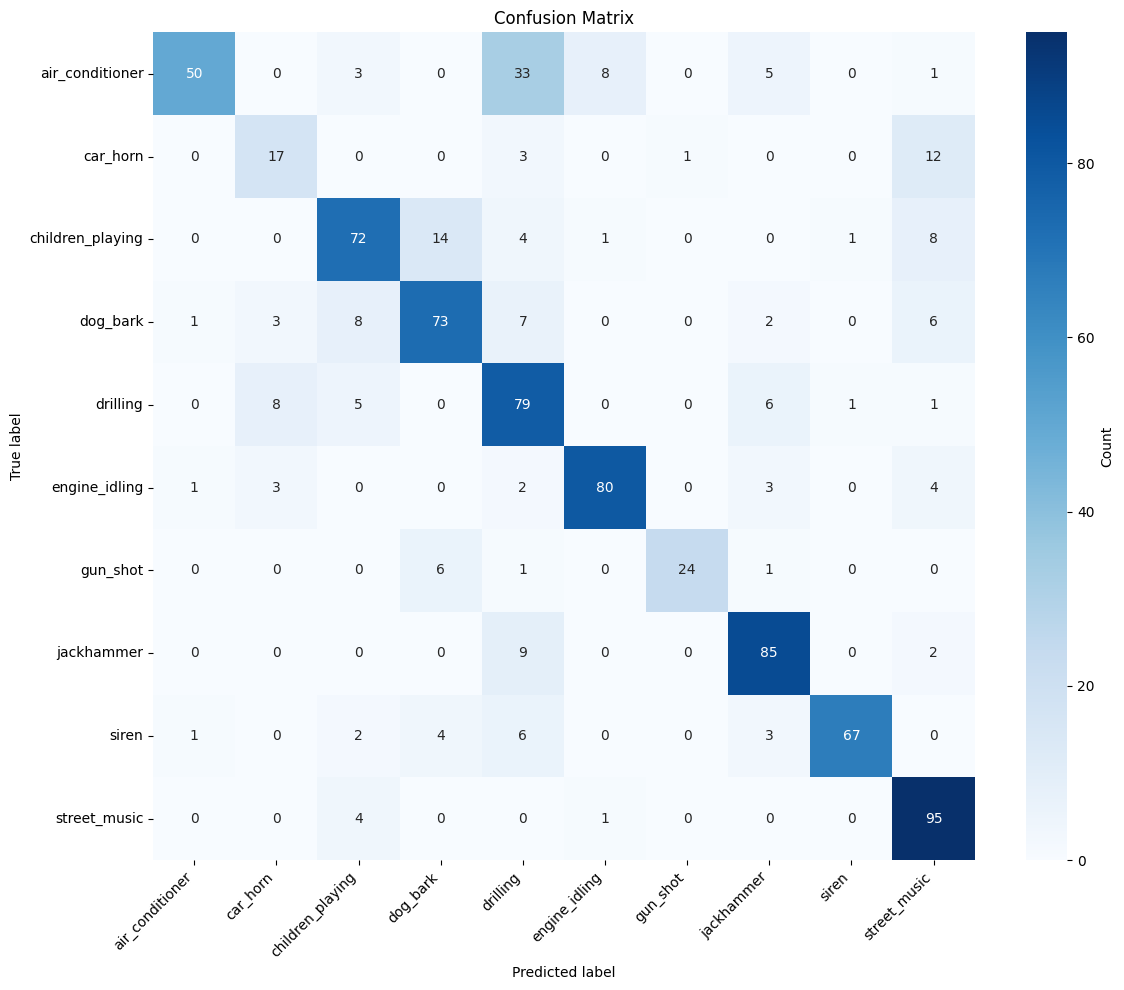

                  precision    recall  f1-score   support

 air_conditioner     0.9434    0.5000    0.6536       100
        car_horn     0.5484    0.5152    0.5312        33
children_playing     0.7660    0.7200    0.7423       100
        dog_bark     0.7526    0.7300    0.7411       100
        drilling     0.5486    0.7900    0.6475       100
   engine_idling     0.8889    0.8602    0.8743        93
        gun_shot     0.9600    0.7500    0.8421        32
      jackhammer     0.8095    0.8854    0.8458        96
           siren     0.9710    0.8072    0.8816        83
    street_music     0.7364    0.9500    0.8297       100

        accuracy                         0.7670       837
       macro avg     0.7925    0.7508    0.7589       837
    weighted avg     0.7939    0.7670    0.7665       837



In [41]:
import seaborn as sns
all_preds = np.load("test_preds.npy")
all_labels = np.load("test_labels.npy")

class_names = global_label_encoder.classes_

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

### Задание 2.4. Финальная 10-fold оценка (2,5 балла)

После того как вы подобрали рабочую конфигурацию на dev-split, проведите один финальный прогон 10-fold cross-validation.

Для каждого `test_fold`:
- `val_fold` берётся как следующий fold по кругу;
- все остальные fold'ы идут в train.

Итоговое качество считается по средней accuracy по всем 10 fold'ам.

In [29]:
def evaluate_10fold(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    dataset_path,
    label_encoder,
    device="cuda",
    verbose=True,
):
    """
    10-fold CV по folds UrbanSound8K
    """
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = UrbanSoundDataset(train_df, dataset_path, label_encoder, augment=True)
        val_ds = UrbanSoundDataset(val_df, dataset_path, label_encoder, augment=False)
        test_ds = UrbanSoundDataset(test_df, dataset_path, label_encoder, augment=False)

        loader_kwargs = dict(num_workers=0, pin_memory=False)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kwargs)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, **loader_kwargs)

        model = model_class(**model_kwargs).to(device)
        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

In [30]:
import copy
from tqdm import tqdm
def my_train_fn(model, train_loader, val_loader, device):
    max_epochs = 8       
    patience = 4
    lr = 1e-3
    weight_decay = 1e-4

    model = model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_correct, train_total = 0, 0
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_correct += (outputs.argmax(1) == targets).sum().item()
            train_total += targets.size(0)

        scheduler.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                preds = model(inputs).argmax(1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
        
        val_acc = correct / total if total > 0 else 0.0
        train_acc = train_correct / train_total if train_total > 0 else 0.0

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        print(f"Epoch {epoch}: train={train_acc:.4f}, val={val_acc:.4f}, best={best_val_acc:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model


In [31]:
accuracies = evaluate_10fold (
    model_class=UrbanSoundCNN,
    model_kwargs={"num_classes": 10, "channels": [1, 16, 32, 64]},
    train_fn=my_train_fn,
    metadata=metadata,
    dataset_path=DATASET_PATH,
    label_encoder=global_label_encoder,
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])


Epoch 1: train=0.1502, val=0.2072, best=0.2072


Epoch 2: train=0.2104, val=0.1892, best=0.2072


Epoch 3: train=0.2307, val=0.1959, best=0.2072


Epoch 4: train=0.2393, val=0.2556, best=0.2556


...

Epoch 4: train=0.2230, val=0.3253, best=0.3253


Epoch 5: train=0.2400, val=0.3184, best=0.3253


Epoch 6: train=0.2486, val=0.3196, best=0.3253


Epoch 7: train=0.2542, val=0.3036, best=0.3253


Epoch 8: train=0.2632, val=0.2852, best=0.3253
Early stopping at epoch 8
Fold 10 accuracy: 29.75%

10-fold CV: 27.00% ± 3.98%


In [ ]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

for i, acc in enumerate(accuracies, 1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\n10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")



Fold 1: 34.02%
Fold 2: 20.95%
Fold 3: 21.41%
Fold 4: 25.25%
Fold 5: 30.02%
Fold 6: 26.12%
Fold 7: 23.87%
Fold 8: 29.40%
Fold 9: 29.17%
Fold 10: 29.75%

10-fold CV: 27.00% ± 3.98%


Баллы за пункт 2.4 начисляются в зависимости от лучшего выполненного порога по средней accuracy в 10-fold CV: чем выше итоговое качество, тем больше доля из 2,5 балла за эту часть.

In [61]:
score_2_4 = 0.0

if mean_acc >= 0.64:
    score_2_4 = 0.5 * 2.5
if mean_acc >= 0.69:
    score_2_4 = 0.6 * 2.5
if mean_acc >= 0.74:
    score_2_4 = 0.7 * 2.5
if mean_acc >= 0.79:
    score_2_4 = 0.8 * 2.5
if mean_acc >= 0.84:
    score_2_4 = 0.9 * 2.5
if mean_acc >= 0.88:
    score_2_4 = 1.0 * 2.5

print(f"Mean CV accuracy: {mean_acc:.4f}")
print(f"Баллы за пункт 2.4: {score_2_4:.2f} / 2.5")

Mean CV accuracy: 0.7900
Баллы за пункт 2.4: 2.00 / 2.5


### Задание 2.5. Краткий анализ (0,5 балла)

В конце прокомментируйте свою работу:

1. Какую архитектуру вы выбрали и почему.
2. Какие аугментации оказались полезными, а какие нет.
3. Что сильнее влияло на качество: сама CNN, preprocessing или параметры обучения.
4. Какие классы модель путала чаще всего и почему это выглядит правдоподобно.
5. Насколько различались результаты между fold'ами.


1. Выбрал более глубокую CNN с увеличивающимся числом каналов (например, 1, 32, 64, 128, 256), потому что она лучше улавливает сложные шаблоны в мел‑спектрограммах и даёт запас мощности при росте данных.
2. SpecAugment с аккуратными масками по времени и частоте реально помогал делать модель устойчивее к помехам, а вот слишком жёсткие маски или чрезмерный шум наоборот портят обучение.
3. Большая роль оказалась за настройкой обучения - подбор learning rate, weight decay и оптимизатора давал самый заметный прирост, предобработка и архитектура тоже важны, но их вклад был менее критичным.
4. Модель чаще смешивала похожие по спектру звуки, например car_horn с street_music и air_conditioner с engine_idling, что логично из‑за пересечения частотных компонентов и фоновых шумов.
5. разброс между фолдами был умеренным (пару процентов), и это объясняется разным уровнем шума и неоднородным распределением классов в отдельных фолдах.